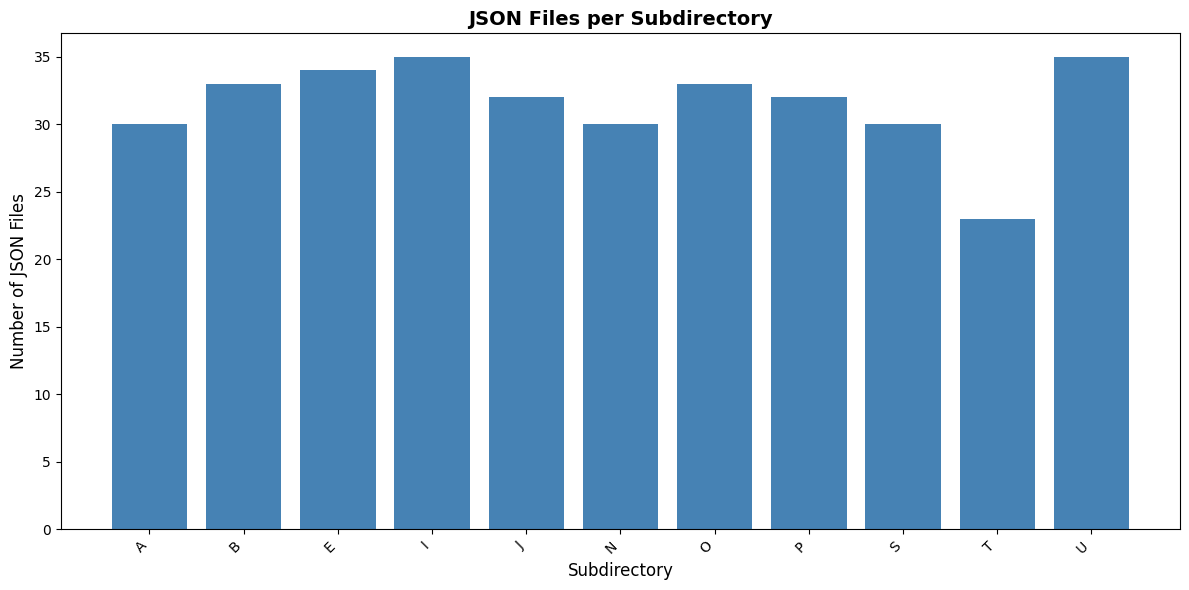


JSON File Counts:
  A: 30
  B: 33
  E: 34
  I: 35
  J: 32
  N: 30
  O: 33
  P: 32
  S: 30
  T: 23
  U: 35
 total: 347


In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt


def plot_json_files_by_subdirectory(directory_path, title="JSON Files per Subdirectory"):
    """
    Create a bar graph showing the number of JSON files in each subdirectory.
    
    Args:
        directory_path (str): Path to the parent directory to analyze
        title (str): Title for the bar graph
    
    Returns:
        dict: Dictionary with subdirectory names as keys and JSON file counts as values
    """
    json_counts = {}
    
    # Get all subdirectories
    try:
        subdirectories = [d for d in os.listdir(directory_path) 
                         if os.path.isdir(os.path.join(directory_path, d))]
    except FileNotFoundError:
        print(f"Error: Directory '{directory_path}' not found.")
        return {}
    
    # Count JSON files in each subdirectory
    for subdir in sorted(subdirectories):
        subdir_path = os.path.join(directory_path, subdir)
        json_files = [f for f in os.listdir(subdir_path) 
                     if f.endswith('.json') and os.path.isfile(os.path.join(subdir_path, f))]
        json_counts[subdir] = len(json_files)
    
    # Create bar graph
    if json_counts:
        subdirs = list(json_counts.keys())
        counts = list(json_counts.values())
        
        plt.figure(figsize=(12, 6))
        plt.bar(subdirs, counts, color='steelblue')
        plt.xlabel('Subdirectory', fontsize=12)
        plt.ylabel('Number of JSON Files', fontsize=12)
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No subdirectories found.")
    
    return json_counts


if __name__ == "__main__":
    directory = r"C:\Users\Oscar Strong\Documents\GitHub\BSL-keypoint-processing\Unproccessed_keypoints_V1"
    counts = plot_json_files_by_subdirectory(directory)
    print("\nJSON File Counts:")
    total=0
    for subdir, count in counts.items():
        print(f"  {subdir}: {count}")
        total += count
    print(f" total: {total}")

